# Information Retrieval System - Final Evaluation
هذا الملف يوضح عملية التقييم لمحرك البحث الذي قمنا ببنائه. سنقوم باختبار النظام باستخدام المقاييس المعتمدة مثل MAP و nDCG.
بالإضافة إلى ذلك، نعرض هنا نتائج خوارزمية LDA لاستخراج المواضيع (Topic Modeling).

In [1]:
import requests
import json
import matplotlib.pyplot as plt
import numpy as np
import pickle
from pathlib import Path

API_URL = "http://localhost:8000"
DATASET = "quora"


## 1. System Evaluation
سنقوم الآن باختبار نموذج `bm25` مع مقارنة الأداء قبل وبعد تفعيل ميزة تحسين الاستعلام (Query Refinement).
أخذنا عينة من الاستعلامات لاختبار النظام ورسم النتائج.

⏳ جاري تقييم جميع الكويريات في الـ qrels. قد يستغرق هذا بضع دقائق...


Exception in callback BaseAsyncIOLoop._handle_events()
handle: <Handle BaseAsyncIOLoop._handle_events()>
Traceback (most recent call last):
  File "c:\Users\n_alb\OneDrive\سطح المكتب\IR_Project\venv\Lib\site-packages\jupyter_client\session.py", line 103, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 56-57: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Python313\Lib\asyncio\events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\n_alb\OneDrive\سطح المكتب\IR_Project\venv\Lib\site-packages\tornado\platform\asyncio.py", line 208, in _handle_events
    handler_func(fileobj, events)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "c:\Users\n_alb\OneDrive\سطح المكتب\IR_Project\venv\Lib\s

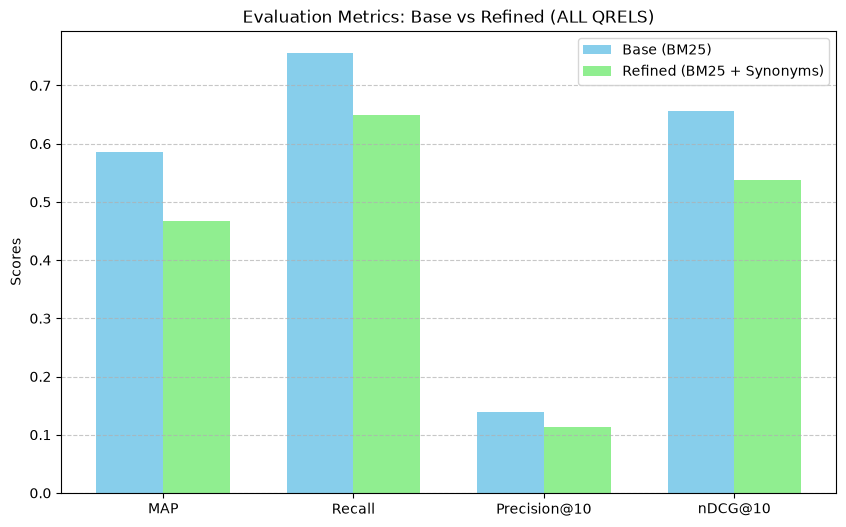

In [2]:
print("\u23f3 \u062c\u0627\u0631\u064a \u062a\u0642\u064a\u064a\u0645 \u062c\u0645\u064a\u0639 \u0627\u0644\u0643\u0648\u064a\u0631\u064a\u0627\u062a \u0641\u064a \u0627\u0644\u0640 qrels. \u0642\u062f \u064a\u0633\u062a\u063a\u0631\u0642 \u0647\u0630\u0627 \u0628\u0636\u0639 \u062f\u0642\u0627\u0626\u0642...")

payload = {
    "dataset": DATASET,
    "model": "bm25",
    "num_queries": 200, # ر\u0642\u0645 \u0636\u062e\u0645 \u0644\u0636\u0645\u0627\u0646 \u062a\u0642\u064a\u064a\u0645 \u0643\u0644 \u0627\u0644\u0627\u0633\u062a\u0639\u0644\u0627\u0645\u0627\u062a \u0641\u064a qrels
    "k": 10,
    "compare_refinement": True
}

response = requests.post(f"{API_URL}/search/evaluate", json=payload)
if response.status_code == 200:
    results = response.json()
    base = results["base"]
    refined = results["refined"]
    
    num_q = base["num_queries"]
    print(f"\u2705 \u062a\u0645\u062a \u0639\u0645\u0644\u064a\u0629 \u0627\u0644\u062a\u0642\u064a\u064a\u0645 \u0628\u0646\u062c\u0627\u062d!")
    print(f"\ud83d\udccc \u0639\u062f\u062f \u0627\u0644\u0627\u0633\u062a\u0639\u0644\u0627\u0645\u0627\u062a (Queries) \u0627\u0644\u062a\u064a \u062a\u0645 \u0627\u0633\u062a\u062e\u062f\u0627\u0645\u0647\u0627 \u0641\u064a \u0627\u0644\u062a\u0642\u064a\u064a\u0645 \u0645\u0646 \u0645\u0644\u0641 \u0627\u0644\u0640 qrels \u0647\u0648: {num_q} \u0627\u0633\u062a\u0639\u0644\u0627\u0645.")
    
    metrics = ['MAP', 'Recall', 'Precision@10', 'nDCG@10']
    base_scores = [base['map'], base['mean_recall'], base['mean_precision_at_k'], base['mean_ndcg_at_k']]
    refined_scores = [refined['map'], refined['mean_recall'], refined['mean_precision_at_k'], refined['mean_ndcg_at_k']]
    
    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width/2, base_scores, width, label='Base (BM25)', color='skyblue')
    ax.bar(x + width/2, refined_scores, width, label='Refined (BM25 + Synonyms)', color='lightgreen')

    ax.set_ylabel('Scores')
    ax.set_title('Evaluation Metrics: Base vs Refined (ALL QRELS)')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()
else:
    print("\u274c \u062e\u0637\u0623 \u0641\u064a \u0627\u0644\u062a\u0642\u064a\u064a\u0645:", response.text)


## 2. Topic Modeling Visualization
قراءة النموذج المدرب وعرض المواضيع المكتشفة مع الكلمات المفتاحية الخاصة بها.

c:\Users\n_alb\OneDrive\سطح المكتب\IR_Project\venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LatentDirichletAllocation from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\n_alb\OneDrive\سطح المكتب\IR_Project\venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator CountVectorizer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


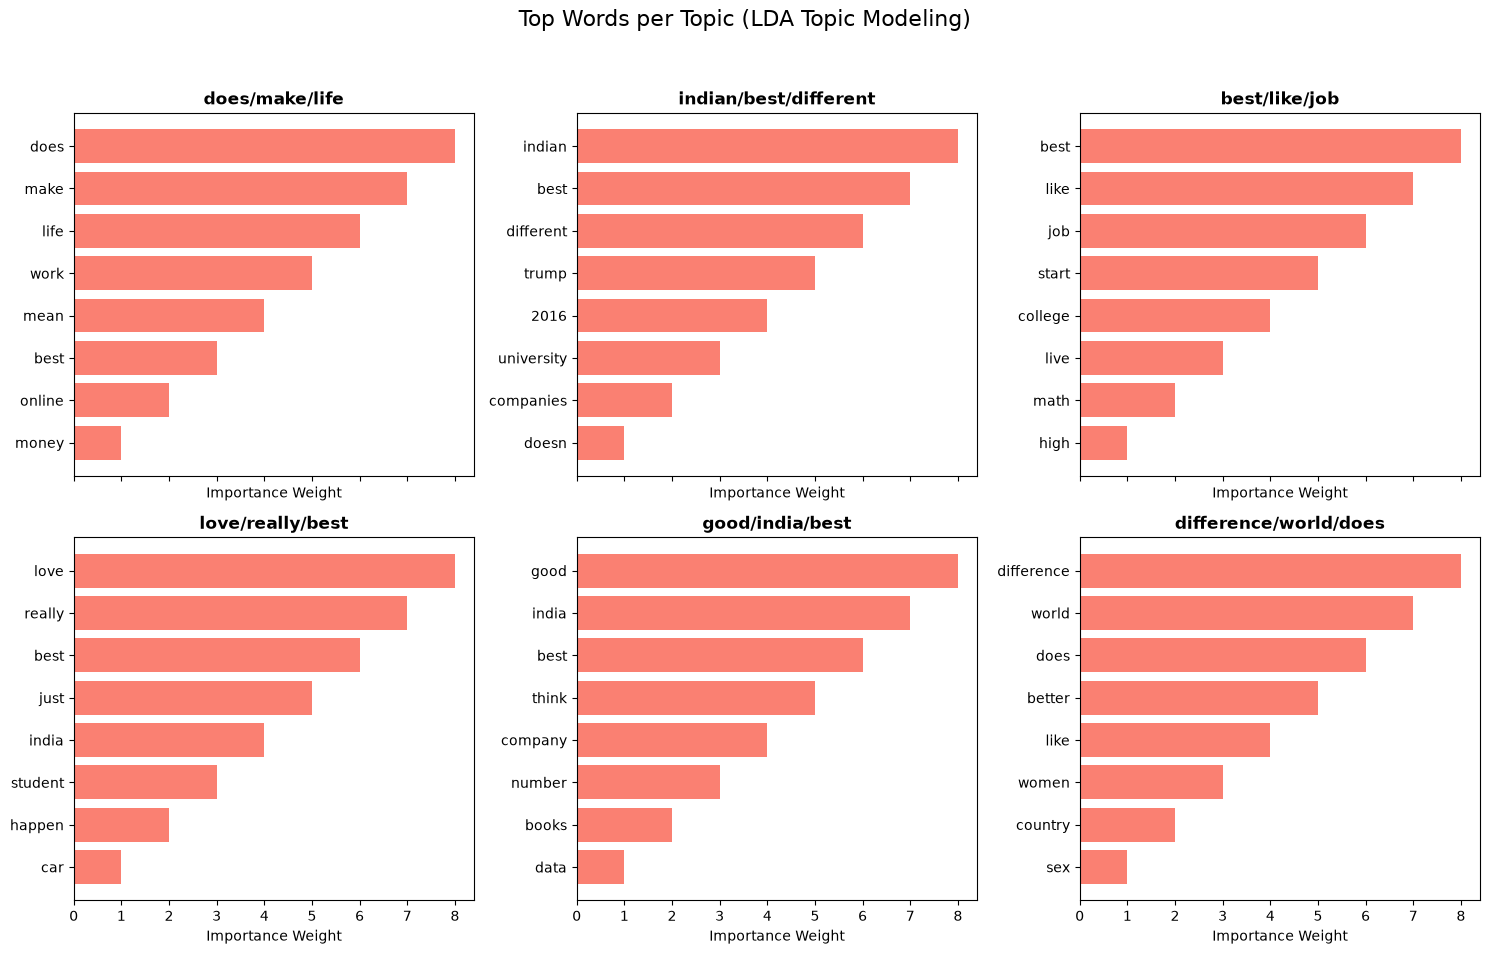

In [3]:
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import sys
import os

# Add backend_services to path to fix pickle load errors
sys.path.append(os.path.abspath('backend_services'))

lda_path = Path("data") / "quora" / "lda_model.pkl"

if not lda_path.exists():
    print(f"\u274c \u0644\u0645 \u064a\u062a\u0645 \u0627\u0644\u0639\u062b\u0648\u0631 \u0639\u0644\u0649 \u0627\u0644\u0646\u0645\u0648\u0630\u062c \u0641\u064a {lda_path}")
else:
    with open(lda_path, 'rb') as f:
        lda_data = pickle.load(f)
    
    topics = lda_data['topics']
    print(f"\ud83d\udccc \u0639\u062f\u062f \u0627\u0644\u0645\u0648\u0627\u0636\u064a\u0639 (Topics) \u0627\u0644\u0645\u0633\u062a\u062e\u0631\u062c\u0629 \u0647\u0648: {len(topics)} \u0645\u0648\u0627\u0636\u064a\u0639.")
    
    num_to_plot = min(6, len(topics))
    fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=True)
    axes = axes.flatten()

    for i in range(num_to_plot):
        top_words = topics[i]['top_words'][:10]
        weights = list(range(len(top_words), 0, -1)) 
        
        ax = axes[i]
        ax.barh(top_words, weights, color='salmon')
        ax.set_title(topics[i]['label'], fontsize=12, fontweight='bold')
        ax.invert_yaxis()
        ax.set_xlabel("Importance Weight")

    plt.suptitle("Top Words per Topic (LDA Topic Modeling)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
